In [133]:
# Animation of four bar

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import matplotlib.animation as animation
import math

%matplotlib widget

In [134]:
# Example analysis of a four-bar mechanism.

# Data initialization (all data is in SI units)
# kinematic parameters (link lengths)
import math


r1 = 2 #m
r2 = r1 #m
r3 = 2 #m
r4 = r3 #m
r5 = 1 #m
r6 = r5 #m
r7_1 = 1 #m
r7_2 = 3 #m
r7 = r7_1 + r7_2 #m
r8 = 4 #m
r9 = r8 #m
r10_1 = r7_1 #m
r10_2 = r7_2 #m
r10 = r10_1 + r10_2 #m
phi10 = math.pi/2 #rad


In [135]:
# STEP 1. Determination of Kinematics

# position analysis
phi1_init = 0.2  # initial condition for first step of position analysis with fsolve (phi3 and phi4)
phi2_init = 2  # VERY IMPORTANT because it determines which branch of the mechanism you're in
phi3_init = 0.2
phi4_init = 2
phi5_init = 0.2
phi6_init = 2
phi7_init = math.pi/2
phi8_init = 2

t_begin =  0     # start time of simulation
t_end   = 15     # end time of simulation
Ts      =  0.05  # time step of simulation
t = np.arange(t_begin, t_end + Ts, Ts)  # time vector

# initialization of driver
omega = 0.5      # driver frequency
A     = 0.4       # amplitude
# angular position, velocity and acceleration:
phi9   = 1 + A * np.sin(omega * t)
dphi9  = omega * A * np.cos(omega * t)
ddphi9 = -omega ** 2 * A * np.sin(omega * t)

In [136]:
# Function to rotate a vector z over an angle theta:
def rotate_vector(z, theta):
    rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                                [np.sin(theta), np.cos(theta)]])
    return np.dot(rotation_matrix, z)

In [137]:
# Define loop closure equations
def loop_closure_eqs(phi_init, phi9, r1, r2, r3, r4, r5, r6, r7, r7_1, r8, r9, r10, r10_1, phi10):
    phi1 = phi_init[0]
    phi2 = phi_init[1]
    phi3 = phi_init[2]
    phi4 = phi_init[3]
    phi5 = phi_init[4]
    phi6 = phi_init[5]
    phi7 = phi_init[6]
    phi8 = phi_init[7]
    
    # Loop closure equations
    F1 = r1 * np.cos(phi1) - r3 * np.cos(phi3) - r5 * np.cos(phi5)+ r10_1 * np.cos(phi10)
    F2 = r1 * np.sin(phi1) - r3 * np.sin(phi3) - r5 * np.sin(phi5) + r10_1 * np.sin(phi10)
    F3 = r2 * np.cos(phi2) - r4 * np.cos(phi4) - r6 * np.cos(phi6) + r7_1 * np.cos(phi7)
    F4 = r2 * np.sin(phi2) - r4 * np.sin(phi4) - r6 * np.sin(phi6) + r7_1 * np.sin(phi7)
    F5 = r3 * np.cos(phi3) - r2 * np.cos(phi2) - r7 * np.cos(phi7) + r8 * np.cos(phi8)
    F6 = r3 * np.sin(phi3) - r2 * np.sin(phi2) - r7 * np.sin(phi7) + r8 * np.sin(phi8)
    F7 = r4 * np.cos(phi4) - r1 * np.cos(phi1) - r10 * np.cos(phi10) + r9 * np.cos(phi9)
    F8 = r4 * np.sin(phi4) - r1 * np.sin(phi1) - r10 * np.sin(phi10) + r9 * np.sin(phi9)

    return [F1, F2, F3, F4, F5, F6, F7, F8]

In [138]:
# Define kinematic computations of the four-bar mechanism

def kinematics_4bar(r1, r2, r3, r4, r5, r6, r7, r7_1, r8, r9, r10, r10_1, phi10, phi9, dphi9, ddphi9, phi1_init, phi2_init, phi3_init, phi4_init, phi5_init, phi6_init, phi7_init, phi8_init, t):
    global phi1, phi2, phi3, phi4, phi5, phi6, phi7, phi8, dphi1, dphi2, dphi3, dphi4, dphi5, dphi6, dphi7, dphi8, ddphi1, ddphi2, ddphi3, ddphi4, ddphi5, ddphi6, ddphi7, ddphi8
    phi1   = np.zeros_like(t)
    phi2   = np.zeros_like(t)
    phi3   = np.zeros_like(t)
    phi4   = np.zeros_like(t)
    phi5   = np.zeros_like(t)
    phi6   = np.zeros_like(t)
    phi7   = np.zeros_like(t)
    phi8   = np.zeros_like(t)
    dphi1  = np.zeros_like(t)
    dphi2  = np.zeros_like(t)
    dphi3  = np.zeros_like(t)
    dphi4  = np.zeros_like(t)
    dphi5  = np.zeros_like(t)
    dphi6  = np.zeros_like(t)
    dphi7  = np.zeros_like(t)
    dphi8  = np.zeros_like(t)
    ddphi1 = np.zeros_like(t)
    ddphi2 = np.zeros_like(t)
    ddphi3 = np.zeros_like(t)
    ddphi4 = np.zeros_like(t)
    ddphi5 = np.zeros_like(t)
    ddphi6 = np.zeros_like(t)
    ddphi7 = np.zeros_like(t)
    ddphi8 = np.zeros_like(t)

    optim_options = {"full_output":True}  # options for fsolve

    for k, time in enumerate(t):
        # Position Analysis
        x, _, ier, message  = fsolve(lambda x: loop_closure_eqs(x, phi9[k], r1, r2, r3, r4, r5, r6, r7, r7_1, r8, r9, r10, r10_1, phi10), [phi1_init, phi2_init, phi3_init, phi4_init, phi5_init, phi6_init, phi7_init, phi8_init], **optim_options)

        if ier != 1:
            print("The fsolve exit flag was not 1, probably no convergence!")
            print(message)

        phi1[k] = x[0]
        phi2[k] = x[1]
        phi3[k] = x[2]
        phi4[k] = x[3]
        phi5[k] = x[4]
        phi6[k] = x[5]
        phi7[k] = x[6]
        phi8[k] = x[7]

        # Velocity Analysis
        A = np.array([  [-r1*np.sin(phi1[k]), 0,  r3*np.sin(phi3[k]), 0,  r5*np.sin(phi5[k]), 0, 0, 0],
                        [ r1*np.cos(phi1[k]), 0, -r3*np.cos(phi3[k]), 0, -r5*np.cos(phi5[k]), 0, 0, 0],
                        [0, -r2*np.sin(phi2[k]), 0,  r4*np.sin(phi4[k]), 0,  r6*np.sin(phi6[k]), -r7_1*np.sin(phi7[k]), 0],
                        [0,  r2*np.cos(phi2[k]), 0, -r4*np.cos(phi4[k]), 0, -r6*np.cos(phi6[k]),  r7_1*np.cos(phi7[k]), 0],
                        [0,  r2*np.sin(phi2[k]), -r3*np.sin(phi3[k]), 0, 0, 0,  r7*np.sin(phi7[k]), -r8*np.sin(phi8[k])],
                        [0, -r2*np.cos(phi2[k]),  r3*np.cos(phi3[k]), 0, 0, 0, -r7*np.cos(phi7[k]),  r8*np.cos(phi8[k])],
                        [ r1*np.sin(phi1[k]), 0, 0, -r4*np.sin(phi4[k]), 0, 0, 0, 0],
                        [ r1*np.cos(phi1[k]), 0, 0, -r4*np.cos(phi4[k]), 0, 0, 0, 0]
                    ])
        B = np.array([  0,
                        0,
                        0,
                        0,
                        0,
                        0,
                        r9 * np.sin(phi9[k]) * dphi9[k],
                        r9 * np.cos(phi9[k]) * dphi9[k]
                        ])
        x = np.linalg.solve(A, B)
        dphi1[k] = x[0]
        dphi2[k] = x[1]
        dphi3[k] = x[2]
        dphi4[k] = x[3]
        dphi5[k] = x[4]
        dphi6[k] = x[5]
        dphi7[k] = x[6]
        dphi8[k] = x[7]

        # Acceleration Analysis
        B = np.array([  r1 * np.cos(phi1[k]) * dphi1[k]**2
                        - r3 * np.cos(phi3[k]) * dphi3[k]**2
                        - r5 * np.cos(phi5[k]) * dphi5[k]**2,
                        r1 * np.sin(phi1[k]) * dphi1[k]**2
                        - r3 * np.sin(phi3[k]) * dphi3[k]**2
                        - r5 * np.sin(phi5[k]) * dphi5[k]**2,
                        r2 * np.cos(phi2[k]) * dphi2[k]**2
                        - r4 * np.cos(phi4[k]) * dphi4[k]**2
                        - r6 * np.cos(phi6[k]) * dphi6[k]**2
                        + r7_1 * np.cos(phi7[k]) * dphi7[k]**2,
                        r2 * np.sin(phi2[k]) * dphi2[k]**2
                        - r4 * np.sin(phi4[k]) * dphi4[k]**2
                        - r6 * np.sin(phi6[k]) * dphi6[k]**2
                        + r7_1 * np.sin(phi7[k]) * dphi7[k]**2,
                        -r3 * np.cos(phi3[k]) * dphi3[k]**2
                        + r2 * np.cos(phi2[k]) * dphi2[k]**2
                        + r7 * np.cos(phi7[k]) * dphi7[k]**2
                        - r8 * np.cos(phi8[k]) * dphi8[k]**2,
                        r3 * np.sin(phi3[k]) * dphi3[k]**2
                        - r2 * np.sin(phi2[k]) * dphi2[k]**2
                        - r7 * np.sin(phi7[k]) * dphi7[k]**2
                        + r8 * np.sin(phi8[k]) * dphi8[k]**2,
                        -r1 * np.cos(phi1[k]) * dphi1[k]**2
                        + r4 * np.cos(phi4[k]) * dphi4[k]**2
                        + r9 * np.cos(phi9[k]) * dphi9[k]**2
                        + r9 * np.sin(phi9[k]) * ddphi9[k],
                        r1 * np.sin(phi1[k]) * dphi1[k]**2
                        - r4 * np.sin(phi4[k]) * dphi4[k]**2
                        - r9 * np.sin(phi9[k]) * dphi9[k]**2
                        + r9 * np.cos(phi9[k]) * ddphi9[k]
                    ])
        x = np.linalg.solve(A, B)
        ddphi1[k] = x[0]
        ddphi2[k] = x[1]
        ddphi3[k] = x[2]
        ddphi4[k] = x[3]
        ddphi5[k] = x[4]
        ddphi6[k] = x[5]
        ddphi7[k] = x[6]
        ddphi8[k] = x[7]

        # Next iteration step
        phi1_init = phi1[k] + (t[1] - t[0]) * dphi1[k]
        phi2_init = phi2[k] + (t[1] - t[0]) * dphi2[k]
        phi3_init = phi3[k] + (t[1] - t[0]) * dphi3[k]
        phi4_init = phi4[k] + (t[1] - t[0]) * dphi4[k]
        phi5_init = phi5[k] + (t[1] - t[0]) * dphi5[k]
        phi6_init = phi6[k] + (t[1] - t[0]) * dphi6[k]
        phi7_init = phi7[k] + (t[1] - t[0]) * dphi7[k]
        phi8_init = phi8[k] + (t[1] - t[0]) * dphi8[k]



    global movie_axes, fig, H, F, Bp
    # next step in the animation:
    def update(frame):
        plt.cla()  # Clear the current axes
        plt.axis('equal')  # Ensures 1 unit on x == 1 unit on y
    
        # Calculate Cartesian coordinates using rotation matrix
        A = Bp + rotate_vector(np.array([r1, 0]), phi1[frame])
        C = A - rotate_vector(np.array([r2, 0]), phi2[frame])
        D1 = A - rotate_vector(np.array([r3, 0]), phi3[frame])
        E1 = A - rotate_vector(np.array([r4, 0]), phi4[frame])
        D2 = F + rotate_vector(np.array([r5, 0]), phi5[frame])
        G = E1 - rotate_vector(np.array([r6, 0]), phi6[frame])
        I = C - rotate_vector(np.array([r7, 0]), phi7[frame])
        D2 = I + rotate_vector(np.array([r8, 0]), phi8[frame])
        E2 = H + rotate_vector(np.array([r9, 0]), phi9[frame])


        loop1 = np.array([Bp, A, D1, D2, F])
        loop2 = np.array([A,C,G,E1,E2,A])
        loop3 = np.array([Bp, A, E1, E2, H])
        loop4 = np.array([C, I, D1, D2, A, C])
    
        plt.plot(loop1[:, 0], loop1[:, 1], '-o')
        plt.axis(movie_axes)
        plt.title(f'Frame {frame}')

    # Update the animation
    global ani, index_vec, index_vec, fig
    ani = animation.FuncAnimation(fig, update, frames=len(index_vec), interval=50)
    plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


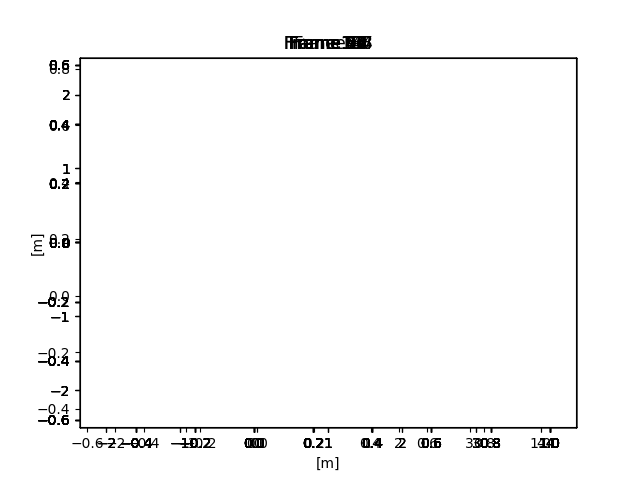

In [ ]:
# Animation of mechanism motion
# compute width and height of drawing canvas:
x_left   = -1.25 * r2
y_bottom = -1.25 * max(r2, r4)
x_right  = r1 + 1.25 * r4
y_top    = 1.25 * max(r2, r4)

# Initialize the figure
plt.close('all')
global fig
fig, ax = plt.subplots(figsize=(6,6))
ax.set_xlim((x_left, x_right))
ax.set_ylim((y_bottom, y_top))
ax.set_xlabel('[m]')
ax.set_ylabel('[m]')

# Define the function to update the plot for each frame:
global movie_axes
movie_axes = [x_left, x_right, y_bottom, y_top]
t_size = len(t)

global H ,F, Bp
# Define point P
# P = 0
Bp = np.array([0,0])

# Define point S
F = rotate_vector(np.array([r10_1, 0]), -phi10)
# Define point H    
H = Bp + rotate_vector(np.array([r10, 0]), -phi10)

# Define the number of fra        mes in the movie
frames = t_size/2
# Calculate the time between frames
delta = int(np.floor(t_size / frames))
# Define the index vector for frames        
global index_vec
index_vec = np.arange(0, t_size, delta)

# calculation and visualisation of the kinematics:
kinematics_4bar(r1, r2, r3, r4, r5, r6, r7, r7_1, r8, r9, r10, r10_1, phi10, phi9, dphi9, ddphi9, phi1_init, phi2_init, phi3_init, phi4_init, phi5_init, phi6_init, phi7_init, phi8_init, t)
    